In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from pandas.core.indexes.api import default_index
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv('economic_index.csv')
df

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254
6,6,2017,6,2.50,5.5,1234
7,7,2017,5,2.25,5.5,1195
8,8,2017,4,2.25,5.5,1159
9,9,2017,3,2.25,5.6,1167


#### INDEX PRICE ( LABEL )

To calculate this index price we just need to use interest_rate and the unemployment_rate feature .

#### MULTIPLE REGRESSION :

As we are using more than 1 feature this becomes a multiple regression model . We are using 2 features to find some correlation between the index price and then based on that predict some things .

In [3]:
df.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [4]:
df

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


In [5]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

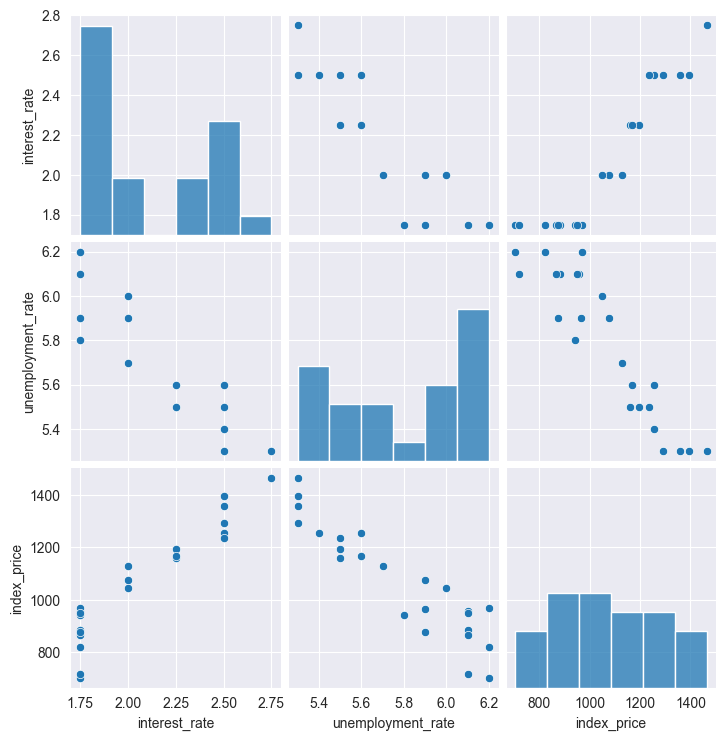

In [6]:
sns.pairplot(df)

##### After plotting we can see that the index price and interest rate has a positive correlation while unemployment rate has an inverse correlation and there is also inverse relation between interest rate and unemployment

In [7]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


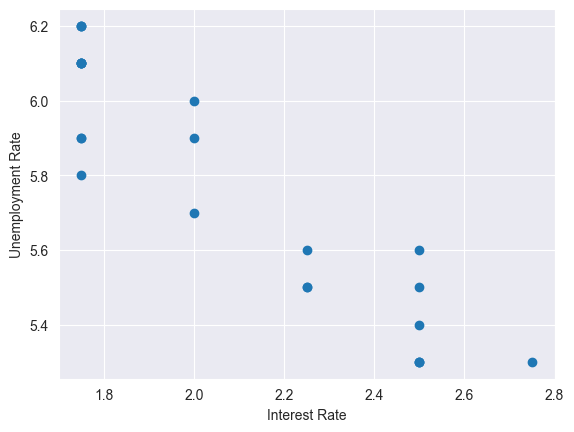

In [8]:
plt.scatter(df['interest_rate'],df['unemployment_rate'])
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.show()

### Data Preprocessing

First we will split the data into independent and dependent features and then we are going to split the features into the training set and the testing set and then we are going to train a multiple linear reg model .

In [9]:
X = df.drop(columns=['index_price'])
y = df["index_price"]

In [10]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

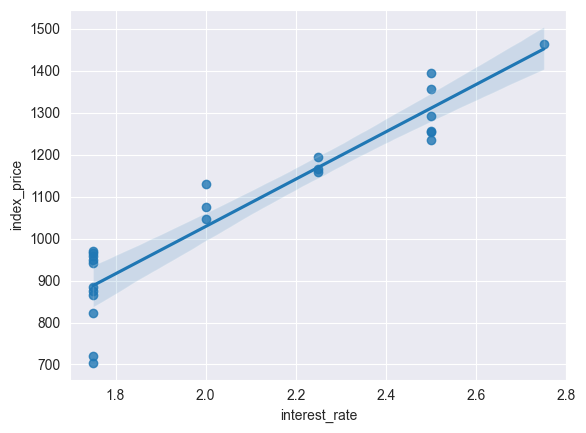

In [12]:
sns.regplot(x=df['interest_rate'],y=df['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

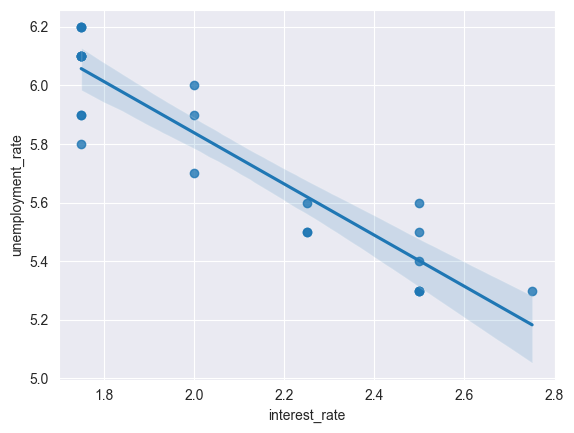

In [13]:
sns.regplot(x=df['interest_rate'],y=df['unemployment_rate'])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

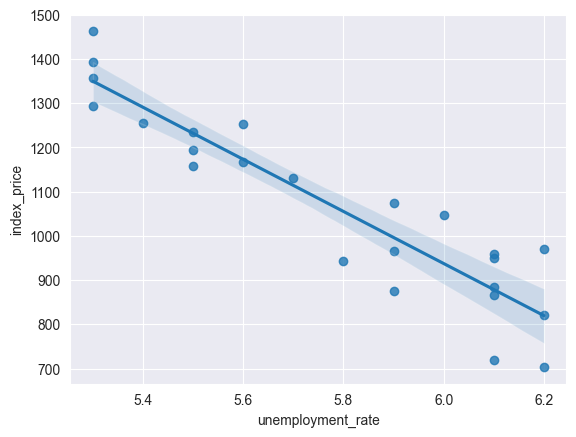

In [14]:
sns.regplot(x=df['unemployment_rate'],y=df['index_price'])

In [15]:
standscaler = StandardScaler()
X_train = standscaler.fit_transform(X_train)
X_test = standscaler.fit_transform(X_test)

In [16]:
linear_reg = LinearRegression()
linear_reg.fit(X_train,y_train)

LinearRegression()

In [17]:
val_score = cross_val_score(linear_reg,X_train,y_train,cv=4,scoring='neg_mean_squared_error')
np.mean(val_score)

np.float64(-6370.018937391778)

### VALIDATION

We are using this cross val score function to get the various scoring or evaluation parameters for different Sections of Traning dataset . So the thing happening here is that parameter " cv " divides the dataset into a number of parts . So lets say our training dataset has 400 values . So what this function will do is that it will divide into 4 parts . SO the first time the model is trained 300 values are for training the other 100 are for testing , then second time a different 100 values are used and other 300 are used for training . This happens till the value of cv is reached .

In [18]:
y_pred = linear_reg.predict(X_test)
y_pred

array([1192.92068422,  846.6908733 , 1374.53556008,  879.61386031,
       1003.34428525])

In [19]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
adjusted_r2 = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(mse,mae,rmse,r2,adjusted_r2)

5952.207497480513 64.74722105636553 77.15055085662391 0.8507000324705947 0.7014000649411893


### ASSUMPTIONS

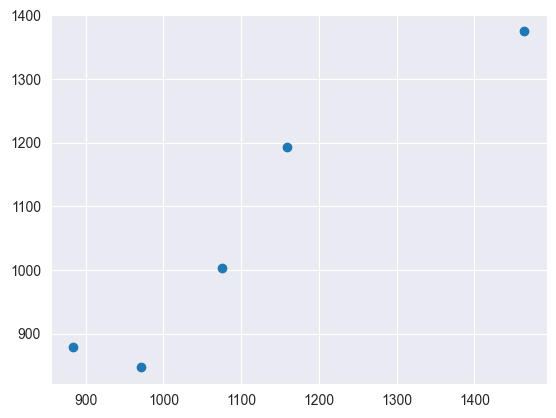

In [20]:
plt.scatter(y_test,y_pred)

In [21]:
residuals = y_test - y_pred
residuals

8     -33.920684
16    124.309127
0      89.464440
18      4.386140
11     71.655715
Name: index_price, dtype: float64

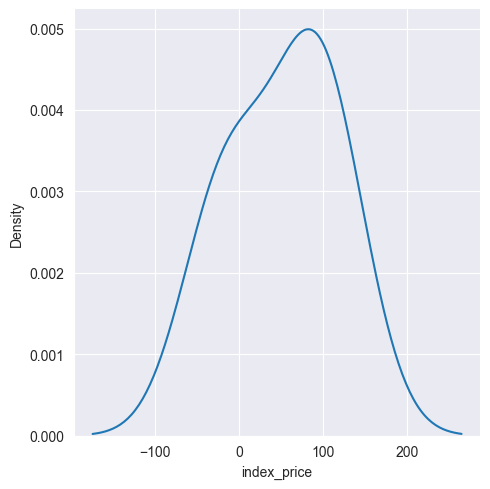

In [22]:
sns.displot(residuals,kind="kde")

# If our KDE plot of residuals shows a bell curver or a normal distribution that means that our model has performed well

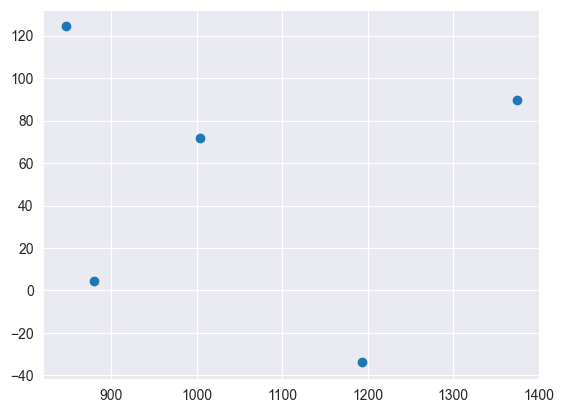

In [23]:
plt.scatter(y_pred,residuals)

# This helps us judge if the predictions made have a uniform distribution or not and this will

### OLS Regression


In [26]:
sm_model = sm.OLS(y_train, X_train).fit()
pred = sm_model.predict(X_test)
pred

array([ 133.49963159, -212.73017933,  315.11450745, -179.80719232,
        -56.07676738])

In [27]:
print(sm_model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.081
Method:                 Least Squares   F-statistic:                             0.2916
Date:                Sun, 14 Sep 2025   Prob (F-statistic):                       0.751
Time:                        00:05:35   Log-Likelihood:                         -159.34
No. Observations:                  19   AIC:                                      322.7
Df Residuals:                      17   BIC:                                      324.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/Users/kalp/PycharmProjects/Machine_learning/.venv/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)


In [28]:
print(linear_reg.coef_)

[  86.63351334 -114.04857249]
